<a href="https://colab.research.google.com/github/arosales23/CIS-3902-AI-ML-ARA-OnlinePurchasingIntent/blob/main/DataMining_Project_Online_Shopping_Intent_Spring_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Mining Project (w/ Online Shoppers Intention Data Set)
## Alan Rosales
## 04/06/2026
## Online Shoppers Purchasing Intention


## Project workflow
This notebook follows an industry-style analytics workflow:

1. **Problem Framing & Data Acquisition**
2. **Exploratory Data Analysis (EDA) & Data Preparation**
3. **Model Development, Evaluation & Business Interpretation**

## GitHub + Colab workflow
1. Create a **new GitHub repository** for your project.
2. Upload this notebook to your repository.
3. In GitHub, open the notebook in **Google Colab**.
4. Commit changes to GitHub as you work.
5. Submit your GitHub repository link when requested.

## Project requirements
- Use a **classification dataset**
- Use **Random Forest** as one of your main models
- Use **Google Colab**
- Include **visualization, preparation, modeling, and interpretation**
- Explain results in a way a manager or stakeholder could understand


In [23]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# AutoViz
!pip install autoviz -q
from autoviz.AutoViz_Class import AutoViz_Class

# scikit-learn tools (Colab-friendly replacement for PyCaret)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report, cohen_kappa_score

# Models to compare
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score

# Problem Framing & Data Acquisition

This data set will be used to predict whether or not a website visitor will make an online purchase or not.

The target variable that will aid in the prediction is the Revenue variable.

Some organizations that can hopefully benefit from this data set are e-commerce retailers, digital marketing agencies, and data analytic firms in general.

This outcome of this data set matters because it may be able to show if an e-commerce business is surviving, and if so, how profitable the business is.

The Online Shoppers Purchasing Intention originally came from [this site](https://archive.ics.uci.edu/ml/datasets/Online+Shoppers+Purchasing+Intention+Dataset). Another source for the same data set comes from [this site](https://www.kaggle.com/datasets/henrysue/online-shoppers-intention).


The Online Shoppers Purchasing Intention data set is one with good variety containing several thousand instances and covers several numerical and categorical variables.


## Data Loading


In [24]:
#@title Loading from Direct CSV URL
data_url = "https://raw.githubusercontent.com/arosales23/CIS-3902-AI-ML-ARA-OnlinePurchasingIntent/refs/heads/main/online_shoppers_intention.csv"
df = pd.read_csv(data_url)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [25]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


# Deliverable 2: Exploratory Data Analysis (EDA) & Data Preparation

## What to include
- basic shape and structure of the data
- variable types
- missing values
- class balance of the target
- visualizations that help explain the data
- preparation steps you used before modeling

## Suggested questions to resolve
- Are there missing values?
- Are the classes balanced?
- Which variables might be useful predictors?
- Are any variables likely to cause problems?
- Do I need to eliminate any variables due to correlation, redundancy, or uniqueness (ex. id)?


In [26]:
#@title Basic Data Inspection (Data Shape)
print("Shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe(include='all').T)


Shape: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Administrative,12330.0,NaN,NaN,NaN,2.315166,3.321784,0.0,0.0,1.0,4.0,27.0
Administrative_Duration,12330.0,NaN,NaN,NaN,80.818611,176.779107,0.0,0.0,7.5,93.25625,3398.75
Informational,12330.0,NaN,NaN,NaN,0.503569,1.270156,0.0,0.0,0.0,0.0,24.0
Informational_Duration,12330.0,NaN,NaN,NaN,34.472398,140.749294,0.0,0.0,0.0,0.0,2549.375
ProductRelated,12330.0,NaN,NaN,NaN,31.731468,44.475503,0.0,7.0,18.0,38.0,705.0
ProductRelated_Duration,12330.0,NaN,NaN,NaN,1194.74622,1913.669288,0.0,184.1375,598.936905,1464.157214,63973.52223
BounceRates,12330.0,NaN,NaN,NaN,0.022191,0.048488,0.0,0.0,0.003112,0.016813,0.2
ExitRates,12330.0,NaN,NaN,NaN,0.043073,0.048597,0.0,0.014286,0.025156,0.05,0.2
PageValues,12330.0,NaN,NaN,NaN,5.889258,18.568437,0.0,0.0,0.0,0.0,361.763742
SpecialDay,12330.0,NaN,NaN,NaN,0.061427,0.198917,0.0,0.0,0.0,0.0,1.0


In [27]:
#@title Missing Values Summary
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary >= 0]
display(missing_summary)

,0
Administrative,0
Administrative_Duration,0
Informational,0
Informational_Duration,0
ProductRelated,0
ProductRelated_Duration,0
BounceRates,0
ExitRates,0
PageValues,0
SpecialDay,0


In [28]:
#@title Establishing a Target
target = "Revenue"

# Class balance
display(df[target].value_counts(dropna=False))
display(df[target].value_counts(normalize=True, dropna=False))


,count
Revenue,
False,10422
True,1908


,proportion
Revenue,
False,0.845255
True,0.154745


In [29]:
#@title Dropping Irrelevant Columns
# Columns to drop:
#   Operating System and Browser wouldn't usually impact a purchase
#   Traffic may be more relevant for marketing purposes, but not predicted a purchase
#   Weekend may be irrelevant for online purchases and more relevant for an in-person purchase
#   Region may have little significance on whether or not someone makes a purchase or not

cols_to_drop = ['OperatingSystems', 'Browser', 'TrafficType', 'Weekend', 'Region']
df = df.drop(columns=cols_to_drop)

In [30]:
#@title Encoding Categorical Variables


# pd.get_dummies() creates one new column per category
# drop_first=True removes one column to avoid redundancy
df = pd.get_dummies(df, columns=['VisitorType'], drop_first=True)



## AutoViz integration

AutoViz is useful for fast exploratory analysis. It can generate many plots at once.

**Important for Colab:** after AutoViz runs, use `plt.close('all')` before creating your own plots later in the notebook. This helps prevent old figures from appearing unexpectedly.


In [31]:
#@title Importing AutoViz

from autoviz.AutoViz_Class import AutoViz_Class
AV = AutoViz_Class()


In [11]:
#@title AutoViz Integration
dfte = AV.AutoViz(
     "",
     sep=",",
     depVar="Revenue",
     dfte=df,
     header=0,
     verbose=1,
     lowess=False,
     chart_format="bokeh",
     max_rows_analyzed=150000,
     max_cols_analyzed=30
     )

%matplotlib inline
import matplotlib.pyplot as plt
plt.close('all')


Shape of your Data Set loaded: (12330, 14)
#######################################################################################
######################## C L A S S I F Y I N G  V A R I A B L E S  ####################
#######################################################################################
Classifying variables in data set...
    Number of Numeric Columns =  7
    Number of Integer-Categorical Columns =  3
    Number of String-Categorical Columns =  1
    Number of Factor-Categorical Columns =  0
    Number of String-Boolean Columns =  2
    Number of Numeric-Boolean Columns =  0
    Number of Discrete String Columns =  0
    Number of NLP String Columns =  0
    Number of Date Time Columns =  0
    Number of ID Columns =  0
    Number of Columns to Delete =  0
    13 Predictors classified...
        No variables removed since no ID or low-information variables found in data set

################ Binary_Classification problem #####################


Row
    [0] WidgetBox
        [0] Select(name='x', options=['Revenue'], value='Revenue')
        [1] Select(name='y', options=['Administrative_Duration'...], value='Administrative_Duration')
    [1] ParamFunction(function, _pane=HoloViews, defer_load=False)

Row
    [0] WidgetBox
        [0] Select(name='X-Axis', options=['Administrative_Duration'...], value='Administrative_Duration')
        [1] Select(name='Y-Axis', options=['Administrative_Duration'...], value='Informational_Duration')
        [2] Select(name='Color', options=['None', 'Revenue'], value='None')
    [1] ParamFunction(function, _pane=HoloViews, defer_load=False)

Column
    [0] Row
        [0] HoloViews(DynamicMap, height=400, sizing_mode='fixed', width=600)
        [1] WidgetBox(align=('end', 'start'))
            [0] Select(options=[np.str_('Month'), ...], value=np.str_('Month'))

Column
    [0] Row
        [0] HoloViews(DynamicMap, height=400, sizing_mode='fixed', width=600)
        [1] WidgetBox(align=('end', 'start'))
            [0] Select(options=[np.str_('BounceRates'), ...], value=np.str_('BounceRates'))

...

HoloViews(Layout)

No date vars could be found in data set


HoloViews(Overlay, height=500, sizing_mode='fixed', width=600)

Row
    [0] WidgetBox
        [0] Select(name='X-Axis', options=['Month', 'Administrative'...], value='Month')
        [1] Select(name='Y-Axis', options=['Administrative_Duration'...], value='Administrative_Duration')
    [1] ParamFunction(function, _pane=HoloViews, defer_load=False)

Time to run AutoViz (in seconds) = 37


## Data Preparation Summary

### Columns Dropped:
Operating System and Browser wouldn't usually impact a purchase

Traffic may be more relevant for marketing purposes, but not predicted a purchase

Weekend may be irrelevant for online purchases and more relevant for an in-person purchase

Region may have little significance on whether or not someone makes a purchase or not

<br>

### Missing Values:
No missing values are in the data set

<br>

### Categorical Variable Encoding:
VisitorType and Month were One-Hot Encoded


# Deliverable 3: Model Development, Evaluation & Interpretation


In [12]:
# Modeling imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    cohen_kappa_score
)

In [13]:
# Identify feature columns
X = df.drop(columns=[target])
y = df[target]

# If needed, convert target labels here
# Example:
df[target] = df[target].astype(int)



categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)


Categorical columns: ['Month', 'VisitorType_Other', 'VisitorType_Returning_Visitor']
Numeric columns: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']


In [14]:
# Build preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=123, stratify=y
)


In [15]:
# Baseline Random Forest model
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=123))
])

rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))

print("Cohen's Kappa:", round(cohen_kappa_score(y_test, y_pred), 4))


Random Forest Classification Report:
              precision    recall  f1-score   support

       False       0.92      0.97      0.95      2084
        True       0.77      0.56      0.65       382

    accuracy                           0.91      2466
   macro avg       0.84      0.77      0.80      2466
weighted avg       0.90      0.91      0.90      2466

Cohen's Kappa: 0.5954


In [32]:
from sklearn.metrics import roc_auc_score

# Get probabilities for the positive class (True)
y_probs = rf_model.predict_proba(X_test)[:, 1]

# Calculate and print AUC
auc = roc_auc_score(y_test, y_probs)
print(f"ROC AUC Score: {round(auc, 4)}")

ROC AUC Score: 0.9223


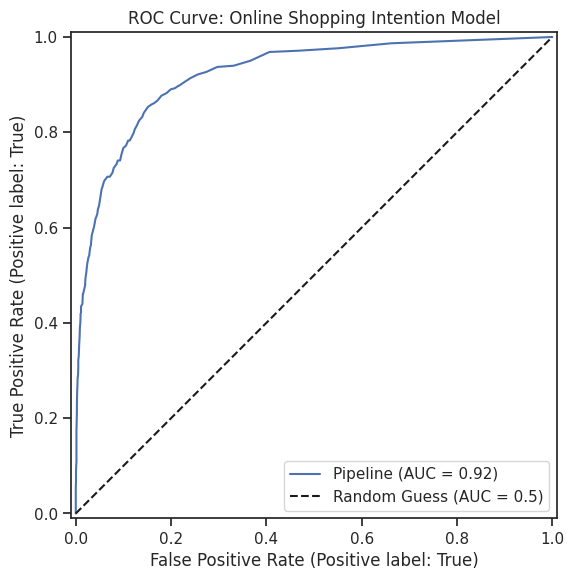

In [33]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Create the plot
fig, ax = plt.subplots(figsize=(8, 6))
RocCurveDisplay.from_estimator(rf_model, X_test, y_test, ax=ax)

# Add a "random guess" baseline (diagonal line)
ax.plot([0, 1], [0, 1], "k--", label="Random Guess (AUC = 0.5)")

ax.set_title("ROC Curve: Online Shopping Intention Model")
ax.legend()
plt.show()

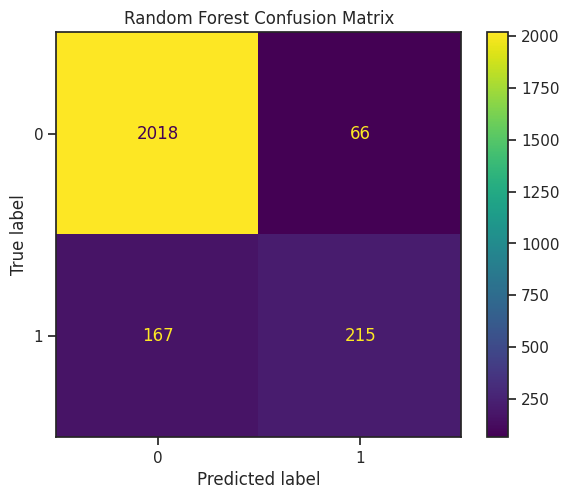

In [16]:
# Confusion matrix
%matplotlib inline
import matplotlib.pyplot as plt


plt.close('all')
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)
ax.set_title("Random Forest Confusion Matrix")
plt.show()



## Hyperparameter tuning

A parameter grid gives the model several choices for each setting. GridSearchCV tests combinations and selects the version that performs best according to the scoring metric.


In [17]:
# Tune the Random Forest model
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

rf_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=123))
])

grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [18]:
# Final evaluation on the test set
best_preds = best_rf.predict(X_test)

print("Tuned Random Forest Classification Report:")
print(classification_report(y_test, best_preds))

kappa = cohen_kappa_score(y_test, best_preds)
print("Cohen's Kappa:", round(kappa, 4))


Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

       False       0.93      0.97      0.95      2084
        True       0.77      0.59      0.67       382

    accuracy                           0.91      2466
   macro avg       0.85      0.78      0.81      2466
weighted avg       0.90      0.91      0.90      2466

Cohen's Kappa: 0.6183


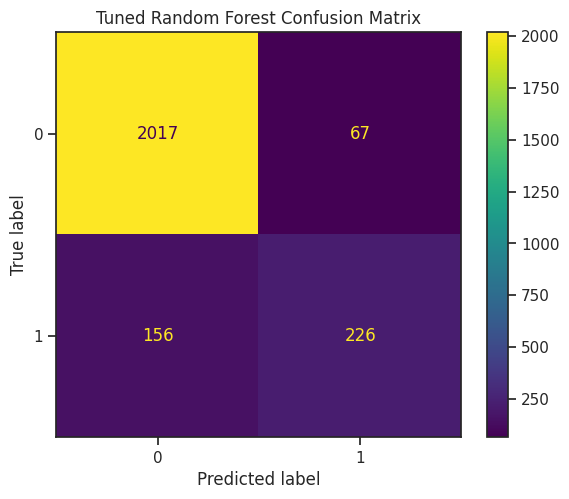

In [19]:
# Tuned confusion matrix
plt.close('all')
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax)
ax.set_title("Tuned Random Forest Confusion Matrix")
plt.show()


## Feature importance

Feature importance helps see which inputs influenced the Random Forest most.



In [20]:
# Feature importance from the tuned model
import pandas as pd

feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out()
importances = best_rf.named_steps["model"].feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(feature_importance_df.head(15))


,feature,importance
8,num__PageValues,0.410217
7,num__ExitRates,0.099285
5,num__ProductRelated_Duration,0.098213
4,num__ProductRelated,0.084537
1,num__Administrative_Duration,0.063566
6,num__BounceRates,0.061950
0,num__Administrative,0.045415
3,num__Informational_Duration,0.031703
17,cat__Month_Nov,0.021752
2,num__Informational,0.020021


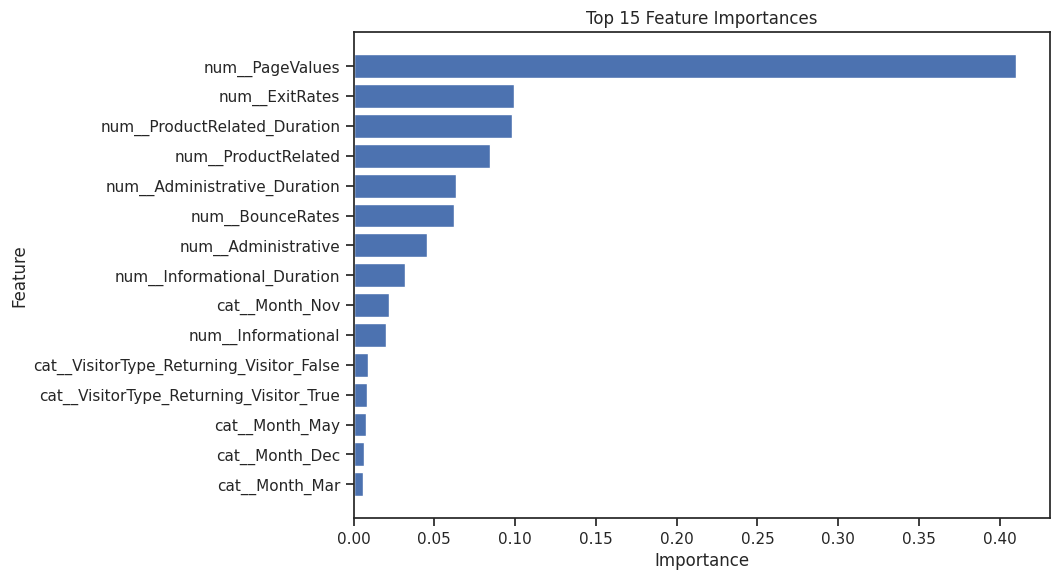

In [21]:
# Plot top feature importances
top_n = 15
top_features = feature_importance_df.head(top_n).sort_values("importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title(f"Top {top_n} Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


### Interpretation summary
The tuned Random Forest achieved an AUC of 0.92, meaning it ranked buyers above non-buyers 92% of the time, which is well above random chance.

Non-purchasers (0) were much easier to predict. 2,017 were correctly identified with only 67 false alarms. Purchasers (1) were harder, with 156 actual buyers missed out of 382 total.

PageValues have an importance score of ~0.41. ExitRates, ProductRelated_Duration, and ProductRelated followed.

The 156 real buyers predicted as non-buyers are the biggest errors. The model was conservative about predicting purchases given the imbalance.

A retailer could flag sessions likely to convert and hold back discounts, while targeting the 156 missed buyers with a timely promotion to recover lost sales.

Trying to reduce the flase negatives should be something that should be improved on.

# Optional: Save your final processed data file and model

You may save your trained model if you want to show a deployment-style step.


In [22]:
import joblib

# Example:
# joblib.dump(best_rf, "final_model.pkl")
# print("Model saved.")

# saving data file
# from google.colab import drive
# drive.mount('/content/drive')

# Save to Drive
# df_clean.to_csv('/content/drive/MyDrive/cleaned_data.csv', index=False)